<a href="https://colab.research.google.com/github/Wanjala-B/MNIST-Multilabel-classification-/blob/main/Multiclass_Classification_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiclass Image Classification of Handwritten Digits

## Project Introduction

This project focuses on building and evaluating a machine learning model for the task of **multiclass image classification**. Specifically, we will be working with the world-renowned **MNIST dataset**, which consists of a large collection of grayscale images of handwritten digits (0 through 9).

The primary objective is to develop a classifier that can accurately identify the digit depicted in each image. We will utilize a **Support Vector Machine (SVM)**, a powerful and versatile algorithm, to achieve this goal. The process will involve data loading, preprocessing (including splitting and scaling), model training, and a detailed evaluation of the model's performance using standard classification metrics.

This notebook serves as a practical demonstration of applying machine learning techniques to a fundamental image classification problem, highlighting key steps from data preparation to model assessment.

In [2]:
from sklearn.datasets import fetch_openml

# Load the MNIST dataset
mnist = fetch_openml("mnist_784", version=1)

# Extract features (X) and target (y)
X, y = mnist["data"], mnist["target"]

# Convert to numpy arrays for scikit-learn compatibility
X = X.to_numpy()
y = y.astype(int).to_numpy()

###  Loading the MNIST Dataset

This cell is responsible for loading the MNIST handwritten digits dataset.

*   `from sklearn.datasets import fetch_openml`: Imports the `fetch_openml` function from scikit-learn, which is used to download datasets from OpenML.
*   `mnist = fetch_openml("mnist_784", version=1)`: Downloads the MNIST dataset. The `"mnist_784"` refers to the dataset ID, and `version=1` specifies a particular version of the dataset.
*   `X, y = mnist["data"], mnist["target"]`: Extracts the feature data (`X`) and the target labels (`y`) from the loaded dataset. `X` contains the pixel values of the images, and `y` contains the corresponding digit labels.
*   `X = X.to_numpy()`: Converts the features `X` (which might be in a pandas DataFrame format) into a NumPy array, which is a standard format for numerical data in scikit-learn.
*   `y = y.astype(int).to_numpy()`: Converts the target labels `y` to integers and then to a NumPy array. This ensures the labels are in a suitable numerical format for classification tasks.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features for SVM
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# For simplicity, let's use the scaled data for the SVM classifier
X_train = X_train_scaled
X_test = X_test_scaled

Data Splitting and Feature Scaling

This cell prepares the dataset for model training by splitting it into training and testing sets and applying feature scaling.

*   `from sklearn.model_selection import train_test_split`: Imports the `train_test_split` function, used to divide a dataset into subsets for training and testing.
*   `from sklearn.preprocessing import StandardScaler`: Imports the `StandardScaler` for standardizing features.
*   `X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)`: Splits the `X` and `y` data.
    *   `test_size=0.2` means 20% of the data will be used for testing, and 80% for training.
    *   `random_state=42` ensures reproducibility of the split.
    *   `stratify=y` ensures that the proportion of classes in the training and testing sets is similar to the original dataset, which is crucial for multiclass problems.
*   `scaler = StandardScaler()`: Initializes a `StandardScaler` object. This scaler standardizes features by removing the mean and scaling to unit variance.
*   `X_train_scaled = scaler.fit_transform(X_train)`: Fits the scaler to the training data (`X_train`) and then transforms it. The `fit` step calculates the mean and standard deviation from the training data, and `transform` applies these statistics to standardize the data.
*   `X_test_scaled = scaler.transform(X_test)`: Transforms the test data (`X_test`) using the *same* scaler fitted on the training data. It's important not to fit the scaler on the test data to prevent data leakage.
*   `X_train = X_train_scaled` and `X_test = X_test_scaled`: Updates `X_train` and `X_test` to use the scaled versions, which are then fed into the SVM classifier.

In [5]:
# Support vector machine
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# Initialize the SVM classifier
SVM_CLF = SVC(random_state=42)

# Train the SVM classifier
SVM_CLF.fit(X_train, y_train)

# Make a prediction for a single digit (e.g., the first test sample)
some_digit = X_test[0].reshape(1, -1)
svm_pred_single = SVM_CLF.predict(some_digit)
print(f"Prediction for single digit (first test sample): {svm_pred_single[0]}")

# Make predictions on the entire test set
y_pred = SVM_CLF.predict(X_test)

# Print the classification report for overall model performance
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Prediction for single digit (first test sample): 7

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.96      0.96      1398
           3       0.97      0.95      0.96      1428
           4       0.97      0.96      0.96      1365
           5       0.97      0.96      0.96      1263
           6       0.97      0.97      0.97      1375
           7       0.92      0.97      0.94      1459
           8       0.97      0.96      0.96      1365
           9       0.96      0.94      0.95      1391

    accuracy                           0.96     14000
   macro avg       0.96      0.96      0.96     14000
weighted avg       0.96      0.96      0.96     14000



### Support Vector Machine (SVM) Model Training and Evaluation

This cell defines, trains, and evaluates a Support Vector Machine classifier on the prepared MNIST dataset.

*   `from sklearn.svm import SVC`: Imports the `SVC` (Support Vector Classifier) class, which implements SVM for classification tasks.
*   `from sklearn.metrics import classification_report`: Imports the `classification_report` function for a detailed evaluation of classification performance.
*   `SVM_CLF = SVC(random_state=42)`: Initializes the SVC model. `random_state=42` ensures reproducibility of the model's internal randomness.
*   `SVM_CLF.fit(X_train, y_train)`: Trains the SVM classifier using the scaled training features (`X_train`) and their corresponding labels (`y_train`). During this step, the SVM learns the optimal hyperplane(s) to separate the different digit classes.
*   `some_digit = X_test[0].reshape(1, -1)`: Selects the first sample from the test set (`X_test`) and reshapes it. `reshape(1, -1)` ensures it's a 2D array, which is the expected input format for the `predict` method, even for a single sample.
*   `svm_pred_single = SVM_CLF.predict(some_digit)`: Makes a prediction for the single digit selected, demonstrating how the model classifies an individual instance.
*   `y_pred = SVM_CLF.predict(X_test)`: Generates predictions for the entire test set (`X_test`). These predictions (`y_pred`) are then compared against the actual test labels (`y_test`) for evaluation.
*   `print("\nClassification Report:")` and `print(classification_report(y_test, y_pred))`: Prints a comprehensive classification report. This report includes precision, recall, f1-score, and support for each digit class (0-9), as well as overall accuracy and macro/weighted averages, providing a detailed breakdown of the model's performance across all classes.

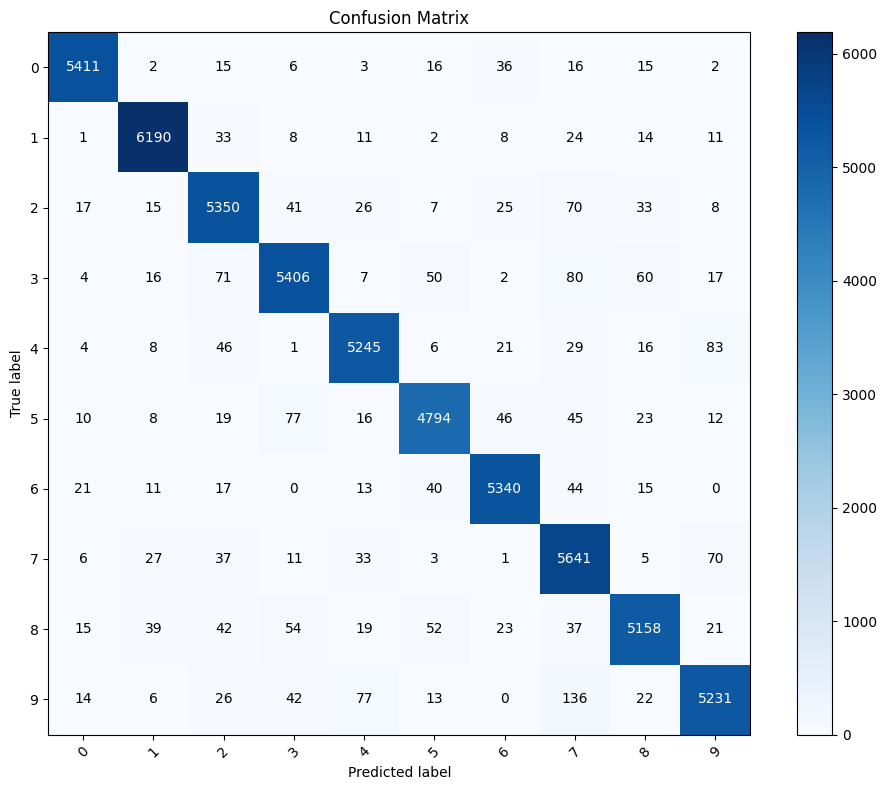

In [7]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(conf_mx, classes, title, cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    plt.imshow(conf_mx, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = 'd'
    thresh = conf_mx.max() / 2.
    for i in range(conf_mx.shape[0]):
        for j in range(conf_mx.shape[1]):
            plt.text(j, i, format(conf_mx[i, j], fmt),
                     ha="center", va="center",
                     color="white" if conf_mx[i, j] > thresh else "black")
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

y_train_pred = cross_val_predict(SVM_CLF, X_train, y_train, cv=3)
conf_mx = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(10, 8))
plot_confusion_matrix(conf_mx, classes=range(10), title="Confusion Matrix")
plt.show()

In [17]:
import os

# A helper function to display a digit
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap="binary", interpolation="nearest")
    plt.axis("off")

# A helper function to save figures
FIGURES_DIR = "figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(FIGURES_DIR, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

### Confusion Matrix Generation and Interpretation

This cell computes and visualizes a **Confusion Matrix**, which is a powerful tool for evaluating the performance of a classification model, especially in multiclass scenarios like the MNIST dataset.

*   `from sklearn.model_selection import cross_val_predict`: Imports `cross_val_predict`, which performs cross-validation and returns predictions for each sample in the input.
*   `from sklearn.metrics import confusion_matrix`: Imports the `confusion_matrix` function, which computes a confusion matrix.
*   `import matplotlib.pyplot as plt` and `import numpy as np`: Imports `matplotlib` for plotting and `numpy` for numerical operations.
*   `def plot_confusion_matrix(...)`: This helper function is defined to create a visually appealing confusion matrix plot. It displays the matrix as a heatmap, with values in each cell indicating counts, and colors representing the magnitude.
*   `y_train_pred = cross_val_predict(SVM_CLF, X_train, y_train, cv=3)`: This line uses 3-fold cross-validation (`cv=3`) to get predictions (`y_train_pred`) for each instance in the training set (`X_train`) using the `SVM_CLF` model. This helps in getting a more robust evaluation of the model's performance on the training data.
*   `conf_mx = confusion_matrix(y_train, y_train_pred)`: Computes the confusion matrix using the actual training labels (`y_train`) and the cross-validated predictions (`y_train_pred`).
*   `plt.figure(figsize=(10, 8))` and `plot_confusion_matrix(...)`: Sets up the figure size and then calls the custom `plot_confusion_matrix` function to display the generated confusion matrix.

#### Interpreting the Confusion Matrix Results:

The confusion matrix is a square matrix where:
*   Each **row** represents the instances of an *actual class*.
*   Each **column** represents the instances of a *predicted class*.
*   The values on the **main diagonal** (top-left to bottom-right) indicate the number of instances that were **correctly classified** for each digit. For example, the cell at row 0, column 0 shows that 5411 instances of the digit '0' were correctly predicted as '0'.
*   **Off-diagonal values** represent misclassifications. For instance, in row 7 (actual digit '7'), there are 70 instances predicted as '9'. This means the model frequently confused '7's with '9's.

**Key Observations from the Confusion Matrix:**
*   **High Diagonal Values:** The majority of the values are concentrated along the main diagonal, indicating that the SVM model is generally performing well at classifying most digits correctly.
*   **Common Misclassifications:** By looking at the off-diagonal entries, we can identify which digits are most often confused with others. For example, digits like '7' and '9' or '3' and '5' show some noticeable misclassifications. This kind of analysis is crucial for identifying areas where the model could be improved, perhaps by feature engineering or using different model architectures.

### Multioutput Classification (Denoising an Image)

This section explores **multioutput classification**, where the model is tasked with predicting multiple labels for each instance. A common application of this is image denoising.

In this experiment, we simulate a noisy version of the MNIST dataset and then train a K-Nearest Neighbors classifier to transform the noisy digit images back into their original, clean counterparts. This means the model outputs 784 pixel values (one for each pixel in the 28x28 image).

*   **Adding Noise**: Random noise is added to both the training (`X_train`) and test (`X_test`) datasets to create `X_train_mod` and `X_test_mod`. The original clean images `X_train` and `X_test` serve as the target labels (`y_train_mod` and `y_test_mod`) for the denoising task.
*   **Training a Denoising Classifier**: A `KNeighborsClassifier` is used, where the input is a noisy image and the output is the corresponding clean image (a multi-dimensional output).
*   **Visualizing Denoising**: We will pick an example noisy digit from the test set and display it alongside its clean version, and then visualize the output of our trained denoising model to see how well it reconstructed the original image.

In [8]:
#Multilabel Image Classification of Handwritten Digits (MNIST)
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

In [12]:
knn_clf.predict(some_digit)

array([[ True,  True]])

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9606647654362332

In [15]:
#Multioutput Classification
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

Saving figure noisy_digit_example_plot


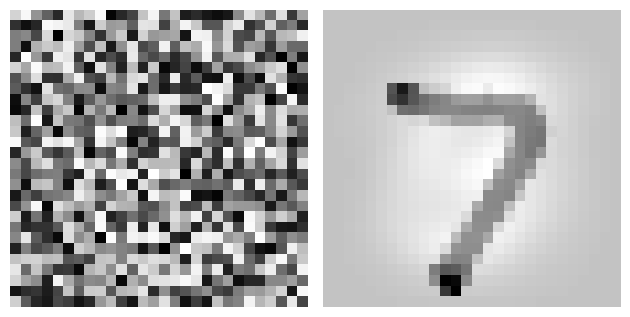

In [18]:
some_index = 0
plt.subplot(121); plot_digit(X_test_mod[some_index])
plt.subplot(122); plot_digit(y_test_mod[some_index])
save_fig("noisy_digit_example_plot")
plt.show()

Saving figure cleaned_digit_example_plot


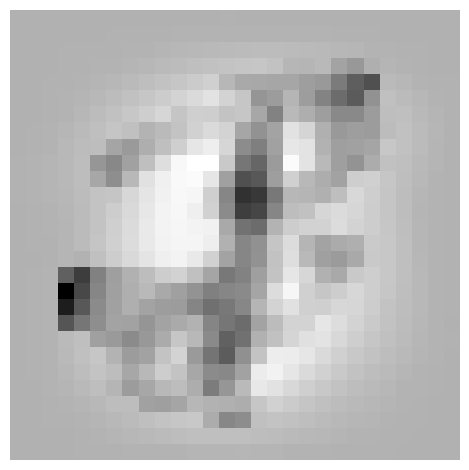

In [21]:
from sklearn.neighbors import KNeighborsRegressor

knn_reg = KNeighborsRegressor()
knn_reg.fit(X_train_mod, y_train_mod)
clean_digit = knn_reg.predict([X_test_mod[some_index]])
plot_digit(clean_digit)
save_fig("cleaned_digit_example_plot")